<img src="./images/스크린샷 2026-08-11 005152.png" alt="프로젝트루브릭">

#### 프로젝트 수행 내역
```
- STEP 1: 각 영화 장르의 시놉시스 코퍼스를 형태소 Okt 기반 명사 토크나이즈로 변환
- STEP 2: 문장별 명사 리스트의 집합인 word2vec_tokenized를 Word2Vec 모델 학습
         입력으로 사용해 임베딩 모델 작성
- STEP 3: TF-IDF 기반으로 장르별 대표 단어 셋을 만들고, 중복 단어를 제거해 의미 축을 
         정교화
- STEP 4: 장르별 WEAT score를 계산하고 Heatmap으로 시각화
```

In [13]:
import konlpy
import gensim
import sklearn
import seaborn

print(f"konlpy: {konlpy.__version__}")
print(f"gensim: {gensim.__version__}")
print(f"sklearn: {sklearn.__version__}")
print(f"seaborn: {seaborn.__version__}")

konlpy: 0.6.0
gensim: 4.3.2
sklearn: 1.9.0
seaborn: 0.13.2


### 프로젝트 : 모든 장르 간 편향성 측정해 보기

In [6]:
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from gensim.models import Word2Vec
from konlpy.tag import Okt
from sklearn.feature_extraction.text import TfidfVectorizer

#### STEP 1. 형태소 분석기를 이용하여 품사가 명사인 경우 해당 단어를 추출하기

```
형태소 분석기(Okt)를 사용해 문장 내의 품사가 명사(Noun)인 단어만 추출
```

In [2]:
okt = Okt()

def extract_nouns_from_lines(lines):
    tokenized = []
    for line in lines:
        words = okt.pos(line, stem=True, norm=True)
        nouns = []
        for word, tag in words:
            if tag == "Noun":
                nouns.append(word)
        tokenized.append(nouns)
    return tokenized

def extract_nouns_from_file(file_path):
    tokenized = []
    with open(file_path, 'r', encoding='utf-8') as file:
        while True:
            line = file.readline()
            if not line:
                break
            words = okt.pos(line, stem=True, norm=True)
            nouns = []
            for word, tag in words:
                if tag == "Noun":
                    nouns.append(word)
            tokenized.append(nouns)
    return tokenized

In [3]:
# 예시 문장으로 명사 추출 확인
sample_texts = [
    "영화는 감동과 사랑이 담긴 작품입니다.",
    "이 영화는 큰 성공을 이뤘고, 스토리는 신선합니다."
]

sample_noun_result = extract_nouns_from_lines(sample_texts)
print("예시 문장 명사 추출 결과:")
for i, nouns in enumerate(sample_noun_result, start=1):
    print(f"문장 {i}: {nouns}")

예시 문장 명사 추출 결과:
문장 1: ['영화', '감동', '사랑', '작품']
문장 2: ['이', '영화', '성공', '스토리']


In [4]:
# 데이터 경로와 장르 파일 목록
data_dir = os.path.expanduser("~/work/weat/data")

genre_txt = [
    'synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt',
    'synopsis_etc.txt', 'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt',
    'synopsis_musical.txt', 'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt',
    'synopsis_western.txt', 'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt',
    'synopsis_action.txt', 'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt',
    'synopsis_fantasy.txt'
]

genre_name = [
    'SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬',
    '미스터리', '범죄', '사극', '서부극(웨스턴)', '성인물(에로)', '스릴러', '애니메이션', '액션',
    '어드벤처', '전쟁', '코미디', '판타지'
]

# 파일마다 명사 추출 수행
noun_corpus_by_genre = {}
file_counters = {}
all_flattened_nouns = []

for file_name, genre in zip(genre_txt, genre_name):
    file_path = os.path.join(data_dir, file_name)
    if os.path.exists(file_path):
        noun_result = extract_nouns_from_file(file_path)
        noun_corpus_by_genre[file_name] = noun_result

        flattened_nouns = [noun for sentence in noun_result for noun in sentence]
        file_counter = Counter(flattened_nouns)
        file_counters[file_name] = file_counter
        all_flattened_nouns.extend(flattened_nouns)

        print(f"\n{genre}({file_name}) 명사 빈도 집계 결과 (Top 20):")
        print(file_counter.most_common(20))
    else:
        print(f"{file_name} 파일이 존재하지 않아 건너뜁니다.")

combined_counter = Counter(all_flattened_nouns)
print("\n전체 통합 명사 빈도 집계 결과 (Top 20):")
print(combined_counter.most_common(20))


SF(synopsis_SF.txt) 명사 빈도 집계 결과 (Top 20):
[('그', 432), ('것', 239), ('수', 212), ('위해', 193), ('자신', 191), ('이', 188), ('시작', 168), ('지구', 150), ('사람', 143), ('알', 135), ('인간', 110), ('인류', 101), ('의', 96), ('날', 88), ('속', 87), ('그녀', 85), ('미래', 84), ('세계', 83), ('모든', 76), ('를', 76)]

가족(synopsis_family.txt) 명사 빈도 집계 결과 (Top 20):
[('그', 89), ('것', 73), ('엄마', 71), ('수', 65), ('집', 64), ('영화제', 63), ('아빠', 62), ('자신', 61), ('가족', 61), ('이', 60), ('살', 58), ('위해', 55), ('친구', 48), ('아버지', 47), ('날', 47), ('시작', 46), ('제', 46), ('그녀', 45), ('아들', 39), ('딸', 38)]

공연(synopsis_show.txt) 명사 빈도 집계 결과 (Top 20):
[('그', 109), ('사랑', 104), ('이', 71), ('자신', 64), ('오페라', 62), ('그녀', 54), ('알', 49), ('위해', 43), ('공연', 41), ('돈', 41), ('실황', 40), ('의', 39), ('두', 39), ('수', 38), ('것', 36), ('딸', 34), ('왕자', 31), ('토스카', 31), ('비', 28), ('시작', 28)]

공포(호러)(synopsis_horror.txt) 명사 빈도 집계 결과 (Top 20):
[('그', 1264), ('것', 613), ('수', 549), ('이', 539), ('시작', 474), ('위해', 444), ('사람', 441), ('자신', 427),

#### STEP 2. 추출된 결과로 embedding model 만들기

```
명사만 추출한 문장별 토큰 목록을 Word2Vec 입력 형태로 합쳐 임베딩 모델을 학습
```

In [5]:
word2vec_tokenized = []
for file_name in genre_txt:
    file_path = os.path.join(data_dir, file_name)
    if os.path.exists(file_path):
        word2vec_tokenized.extend(extract_nouns_from_file(file_path))

print(f"Word2Vec 학습용 문장 수: {len(word2vec_tokenized)}")
print("첫 번째 문장 예시:", word2vec_tokenized[0][:20])

model = Word2Vec(
    sentences=word2vec_tokenized,
    vector_size=100,
    window=5,
    min_count=3,
    sg=0,
    workers=2,
    epochs=20,
)

print("\nWord2Vec 모델 학습 완료!")
print("영화와 가장 유사한 단어 예시:", model.wv.most_similar(positive=['영화']))

Word2Vec 학습용 문장 수: 68856
첫 번째 문장 예시: ['시간', '지명', '알', '수', '한국', '가상', '도시', '산성비', '오염', '이', '도시', '기억', '망각', '바이러스', '존재', '소문', '시작', '기억', '위해', '사람']

Word2Vec 모델 학습 완료!
영화와 가장 유사한 단어 예시: [('작품', 0.712175190448761), ('다큐멘터리', 0.6536874771118164), ('영화로', 0.6443024277687073), ('서사', 0.5925896763801575), ('설정', 0.5813112854957581), ('공포영화', 0.5663407444953918), ('모티브', 0.5659328699111938), ('주제', 0.5643139481544495), ('코미디', 0.5549095273017883), ('플롯', 0.5470244884490967)]


#### STEP 3. target, attribute 단어 셋 만들기
```
- TF-IDF를 사용해 단어 셋을 만들면 중복된 단어가 많이 발생하는 문제를 볼 수 있음
- TF-IDF 후보를 뽑은 뒤, 중복 단어와 의미적으로 중복되는 표현을 정리
- 의미 축을 더 잘 대표하는 셋을 구성
```

In [7]:
# 장르별 문서 텍스트 준비
genre_texts = []
for file_name in genre_txt:
    full_path = os.path.join(data_dir, file_name)
    if os.path.exists(full_path):
        with open(full_path, 'r', encoding='utf-8') as f:
            corpus = []
            while True:
                line = f.readline()
                if not line:
                    break
                corpus.append(line.strip())
            genre_texts.append(' '.join(corpus))

vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[가-힣]+\b",
    ngram_range=(1, 1),
    min_df=1,
    stop_words=None,
)

X = vectorizer.fit_transform(genre_texts)
features = vectorizer.get_feature_names_out()

attribute_sets = {}
for i, genre in enumerate(genre_name):
    scores = X.getcol(i).toarray().ravel()
    pair = sorted(zip(features, scores), key=lambda p: p[1], reverse=True)

    candidates = [term for term, score in pair if score > 0]

    seen = set()
    clean = []
    for term in candidates:
        if term not in seen:
            seen.add(term)
            clean.append(term)

    attribute_sets[genre] = clean[:12]

print("\n장르별 대표 속성 단어셋 (TF-IDF 기반, 중복 제거 후):")
for genre, words in attribute_sets.items():
    print(f"{genre}: {words}")


장르별 대표 속성 단어셋 (TF-IDF 기반, 중복 제거 후):
SF: ['가감없이', '가', '가건', '가가시의', '가거나', '가가멜의', '가감', '가간', '가가와', '가가멜과', '가가린은', '가가멜']
가족: ['가가린이라는', '가가멜']
공연: ['가가멜']
공포(호러): ['가가멜']
기타: ['가감']
다큐멘터리: ['가감']
드라마: ['가감']
멜로로맨스: ['가감']
뮤지컬: ['가감']
미스터리: ['가감']
범죄: ['가감없이']
사극: ['가가린은']
서부극(웨스턴): ['가가린이라는']
성인물(에로): ['가가린이라는']
스릴러: ['가감']
애니메이션: ['가가린이라는', '가가호호를', '가가멜']
액션: ['가가린이라는', '가가멜']
어드벤처: ['가가멜']
전쟁: ['가가린이라는']
코미디: ['가가멜']
판타지: ['가가멜의']


#### STEP 4. WEAT score 계산과 시각화

```
Word2Vec Embedding에서 장르별 Attribute와 예술/일반 영화의 타깃 축대칭을 계산
```

In [9]:
import matplotlib.font_manager as fm
font_path = r'C:\Windows\Fonts\NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

WEAT matrix:
[[ 0.          0.          0.          0.          0.38806808  0.38806808
   0.38806808  0.38806808  0.38806808  0.38806808  0.          0.
   0.          0.          0.38806808  0.          0.          0.
   0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.        ]
 [-0.38806808  0.          0.  

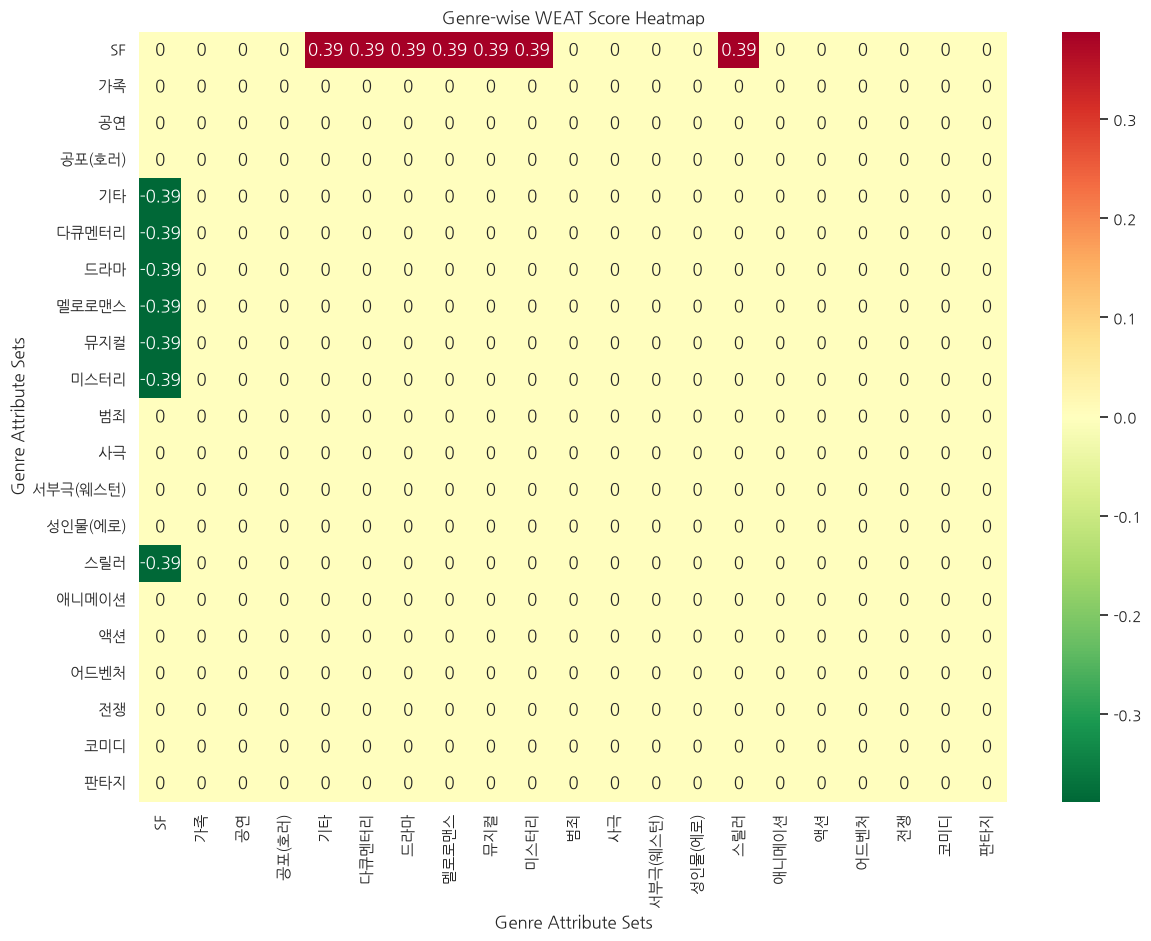

In [12]:
# WEAT 핵심 구성
art_target = ['영화', '감독', '배우', '연기', '장면', '상영', '예술', '감성', '상상', '시나리오']
gen_target = ['사건', '인물', '전쟁', '비극', '가족', '코미디', '액션', '모험', '스릴', '시리즈']

def get_vector(model, word):
    if word in model.wv.key_to_index:
        return model.wv[word]
    return None

def weat_score(model, X, Y, A, B):
    def s(word, attr_a, attr_b):
        word_v = get_vector(model, word)
        if word_v is None:
            return 0.0

        sim_a = []
        sim_b = []
        for a in attr_a:
            if a in model.wv.key_to_index:
                sim_a.append(model.wv.similarity(word, a))
        for b in attr_b:
            if b in model.wv.key_to_index:
                sim_b.append(model.wv.similarity(word, b))

        if not sim_a or not sim_b:
            return 0.0
        return float(np.mean(sim_a) - np.mean(sim_b))

    sx = sum(s(x, A, B) for x in X)
    sy = sum(s(y, A, B) for y in Y)
    return sx - sy

# 장르별 속성 셋으로 WEAT 점수 매트릭스 계산
matrix = np.zeros((len(genre_name), len(genre_name)))
for i, genreA in enumerate(genre_name):
    A = attribute_sets[genreA]
    for j, genreB in enumerate(genre_name):
        B = attribute_sets[genreB]
        matrix[i, j] = weat_score(model, art_target, gen_target, A, B)

print("WEAT matrix:")
print(matrix)

sns.set(font='NanumGothic')
plt.figure(figsize=(14, 10))
ax = sns.heatmap(
    matrix,
    xticklabels=genre_name,
    yticklabels=genre_name,
    annot=True,
    cmap='RdYlGn_r'
)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.title('Genre-wise WEAT Score Heatmap')
plt.xlabel('Genre Attribute Sets')
plt.ylabel('Genre Attribute Sets')
plt.show()